<a href="https://colab.research.google.com/github/MexicoHamburger/AIP-2/blob/main/CarrerPrediction_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TabTransformer Multi‑Task Workflow
엔드‑투‑엔드 예시 노트북 (10 % 샘플·train/val/test 분할 포함)

> Stack Overflow Dev Survey 2024 전처리 결과 CSV를 업로드한 뒤, **`DATA_CSV` 변수 경로만 수정**하고 셀을 순서대로 실행하세요.

In [ ]:
!pip install pandas scikit-learn torch tabtransformer-pytorch matplotlib --quiet

## 1. 데이터 로드 & 10 % 샘플링

In [52]:
import pandas as pd, numpy as np, os, random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from google.colab import files
import io

# --- 파일 업로드 ---
uploaded = files.upload()
filename = next(iter(uploaded))  # 업로드한 첫 번째 파일명
DATA_CSV = filename

# --- 다중-라벨 컬럼 정의 ---
multi_cols = [
    "LanguageHaveWorkedWith", "LanguageWantToWorkWith",
    "DatabaseHaveWorkedWith", "DatabaseWantToWorkWith",
    "PlatformHaveWorkedWith", "PlatformWantToWorkWith",
    "WebframeHaveWorkedWith", "WebframeWantToWorkWith",
    "EmbeddedHaveWorkedWith", "EmbeddedWantToWorkWith",
    "MiscTechHaveWorkedWith", "MiscTechWantToWorkWith",
    "ToolsTechHaveWorkedWith", "ToolsTechWantToWorkWith",
    "ProfessionalTech", "ProfessionalCloud",
    "AISearchDevHaveWorkedWith", "AISearchDevWantToWorkWith"
]

def split_pipe(x):
    """예: 'A;B;C' → ['A','B','C']"""
    return [] if pd.isna(x) else [i.strip() for i in x.split(";")]

# --- 파일 읽기 ---
raw = pd.read_csv(io.BytesIO(uploaded[DATA_CSV]))

# 문자열 → 리스트 변환
for c in multi_cols:
    if c in raw.columns:
        raw[c] = raw[c].apply(split_pipe)

# 핵심 숫자 결측 제거
raw = raw.dropna(subset=["CompTotal", "JobSat"])

# 10 % 샘플링
raw = raw.sample(frac=0.10, random_state=42).reset_index(drop=True)

print("샘플 수:", len(raw))
raw.head(3)


Saving SODC_2024.csv to SODC_2024 (3).csv
샘플 수: 1228


,DevType,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,PlatformHaveWorkedWith,PlatformWantToWorkWith,WebframeHaveWorkedWith,WebframeWantToWorkWith,...,MiscTechWantToWorkWith,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSat
0,"Developer, back-end",230571000.0,"[Bash/Shell (all shells), C#, HTML/CSS, JavaSc...","[C#, HTML/CSS, Rust, SQL]","[Dynamodb, Elasticsearch, Microsoft SQL Server...","[PostgreSQL, SQLite]",[Amazon Web Services (AWS)],[Amazon Web Services (AWS)],"[ASP.NET, React]","[ASP.NET, Blazor, Htmx]",...,"[.NET (5+), RabbitMQ]","[Chocolatey, Docker, Kubernetes, MSBuild, npm,...","[Docker, npm, NuGet]",[],[],"[DevOps function, Observability tools, Microse...",[Hybrid (on-prem and cloud)],Slack search,Fintech,7.0
1,"Developer, full-stack",14100000.0,"[C, C++, TypeScript]","[C, C++, TypeScript]",[SQLite],[],[],[],"[Angular, AngularJS, Laravel, Vue.js]",[],...,"[CUDA, Flutter]","[Composer, Docker, Kubernetes, Make]",[Make],[],[],[Continuous integration (CI) and (more often) ...,[Cloud only (single or multi-cloud)],Traditional public search engine,Software Development,8.0
2,"Developer, back-end",274000000.0,"[Bash/Shell (all shells), C, C++, Go, JavaScri...","[Bash/Shell (all shells), C, Go, Rust, SQL]","[MongoDB, PostgreSQL, Redis]","[MongoDB, PostgreSQL, Redis]","[Amazon Web Services (AWS), Google Cloud, Micr...",[Google Cloud],[],[],...,[],"[Ansible, APT, Docker, Homebrew, Kubernetes, M...","[Ansible, APT, Docker, Homebrew]",[GitHub Copilot],[GitHub Copilot],"[DevOps function, Automated testing, Observabi...",[Hybrid (on-prem and cloud)],AI-powered search (paid),Banking/Financial Services,10.0


## 2. Multi‑Label Binarizer → 입·출력 행렬

In [53]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

# 멀티-라벨 → 멀티-핫
mlb = {c: MultiLabelBinarizer().fit(raw[c]) for c in multi_cols}
X_parts = [mlb[c].transform(raw[c]) for c in multi_cols]
X = np.hstack(X_parts).astype("float32")

# 연봉 표준화
scaler = StandardScaler()
y_sal = scaler.fit_transform(raw["CompTotal"].values.reshape(-1, 1)).flatten()

# 나머지 타깃
y_sat  = raw["JobSat"].astype("float32").values
y_role = raw["DevType"].str.get_dummies(";").astype("float32").values
y_ind  = raw["Industry"].str.get_dummies(";").astype("float32").values


## 3. train / val / test 3‑way split

In [54]:

TEST_RATIO = 0.20  # 20 %
VAL_RATIO  = 0.16  # 16 % 전체

# ① train+val vs test
X_tmp, X_test, yR_tmp, yR_test, yI_tmp, yI_test, yS_tmp, yS_test, yT_tmp, yT_test = train_test_split(
    X, y_role, y_ind, y_sal, y_sat, test_size=TEST_RATIO, random_state=42)

# ② train vs val (val 비율을 나머지에서 다시 적용)
val_ratio_adj = VAL_RATIO / (1 - TEST_RATIO)  # 0.16 / 0.80 = 0.20
X_train, X_val, yR_train, yR_val, yI_train, yI_val, yS_train, yS_val, yT_train, yT_val = train_test_split(
    X_tmp, yR_tmp, yI_tmp, yS_tmp, yT_tmp, test_size=val_ratio_adj, random_state=42)

for name, arr in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"{name:<5}  {arr.shape[0]:>6} samples")


train     785 samples
val       197 samples
test      246 samples


## 4. TabTransformer 모델 정의

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# TabTransformer 정의 (직접 구현한 버전)
class TabTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim=64, depth=4, heads=8, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, activation='gelu', batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, input_dim) → (batch, 1, embed_dim)
        x = self.embedding(x).unsqueeze(1)
        x = self.encoder(x)  # (batch, 1, embed_dim)
        return self.dropout(x.mean(dim=1))  # mean pooling

# MultiTaskTab 모델 정의
class MultiTaskTab(nn.Module):
    def __init__(self, in_dim, n_role, n_ind):
        super().__init__()
        self.backbone = TabTransformer(input_dim=in_dim, embed_dim=64, depth=4, heads=8, dropout=0.2)
        self.role_head = nn.Sequential(nn.Linear(64, n_role), nn.Sigmoid())
        self.ind_head  = nn.Sequential(nn.Linear(64, n_ind),  nn.Sigmoid())
        self.sal_head  = nn.Linear(64, 1)
        self.sat_head  = nn.Linear(64, 1)

    def forward(self, x):
        feat = self.backbone(x)
        return (self.role_head(feat),
                self.ind_head(feat),
                self.sal_head(feat).squeeze(1),
                self.sat_head(feat).squeeze(1))


## 5. DataLoader & 하이퍼파라미터 설정

In [56]:

device = "cuda" if torch.cuda.is_available() else "cpu"

def make_loader(X, yR, yI, yS, yT, bs, shuffle):
    ds = TensorDataset(torch.tensor(X), torch.tensor(yR),
                       torch.tensor(yI), torch.tensor(yS), torch.tensor(yT))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

tr_loader  = make_loader(X_train, yR_train, yI_train, yS_train, yT_train, bs=256, shuffle=True)
val_loader = make_loader(X_val,   yR_val,   yI_val,   yS_val,   yT_val,   bs=512, shuffle=False)
test_loader= make_loader(X_test,  yR_test,  yI_test,  yS_test,  yT_test,  bs=512, shuffle=False)

model = MultiTaskTab(X.shape[1], y_role.shape[1], y_ind.shape[1]).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

def loss_fn(outputs, yR, yI, yS, yT):
    r, i, s, t = outputs
    return (F.binary_cross_entropy(r, yR) +
            F.binary_cross_entropy(i, yI) +
            0.001 * F.l1_loss(s, yS) +
            0.1  * F.mse_loss(t, yT))


## 6. 학습 루프 (Epoch 50, 과적합 관찰)

In [57]:
EPOCHS = 30
history = {"train": [], "val": []}

for ep in range(1, EPOCHS+1):
    # --- Training ---
    model.train()
    total_loss = 0.0
    n_total = 0

    for xb, yR, yI, yS, yT in tr_loader:
        xb, yR, yI, yS, yT = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yR, yI, yS, yT)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        total_loss += loss.item() * len(xb)
        n_total += len(xb)

    train_loss = total_loss / n_total
    history["train"].append(train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for xb, yR, yI, yS, yT in val_loader:
            xb, yR, yI, yS, yT = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device)
            batch_loss = loss_fn(model(xb), yR, yI, yS, yT)

            # ✅ NaN/inf 방지
            if not torch.isnan(batch_loss) and not torch.isinf(batch_loss):
                val_loss += batch_loss.item() * len(xb)
                n_val += len(xb)

    val_avg = val_loss / n_val if n_val > 0 else float('inf')
    history["val"].append(val_avg)

    # --- 로그 출력 ---
    if ep % 10 == 0 or ep == 1 or ep == EPOCHS:
        print(f"Epoch {ep:3d} | train={train_loss:.4f} | val={val_avg:.4f}")


Epoch   1 | train=6.6081 | val=4.2682
Epoch  10 | train=1.4985 | val=1.2488
Epoch  20 | train=0.8746 | val=0.8372
Epoch  30 | train=0.8269 | val=0.8218


## 7. Train vs Val Loss 곡선

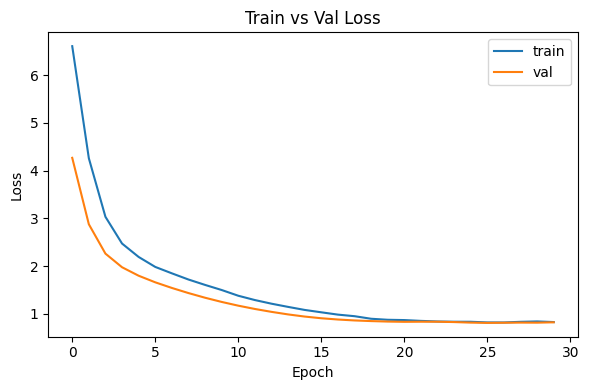

In [58]:

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.title("Train vs Val Loss")
plt.tight_layout(); plt.show()


## 8. Test 세트 최종 평가

In [59]:
model.eval()
test_loss, n = 0.0, 0

with torch.no_grad():
    for xb, yR, yI, yS, yT in test_loader:
        xb, yR, yI, yS, yT = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device)
        tl = loss_fn(model(xb), yR, yI, yS, yT)

        # ✅ NaN 또는 inf 값은 제외
        if not torch.isnan(tl) and not torch.isinf(tl):
            test_loss += tl.item() * len(xb)
            n += len(xb)

# ✅ n이 0일 경우 예외 처리
test_avg = test_loss / n if n > 0 else float('inf')
print(f"Test loss: {test_avg:.4f}")


Test loss: 0.8196


# =========================================
# 🔍 9. Dummy 입력 → 모델 예측 & 읽기-쉬운 출력
# =========================================

In [60]:
import numpy as np, pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ---------- 1. 가상의 스택 ----------
dummy_input = {
    "LanguageHaveWorkedWith":  ["Python", "C"],
    "DatabaseHaveWorkedWith":  ["SQLite"],
    "PlatformHaveWorkedWith":  ["Amazon Web Services (AWS)"],
    "WebframeHaveWorkedWith":  ["FastAPI", "React" ,"Flask"],
    "EmbeddedHaveWorkedWith":  ["GNU GCC"],
    "MiscTechHaveWorkedWith":  ["Docker", "NumPy", "Torch/PyTorch"],
    "ToolsTechHaveWorkedWith":  ["Docker"],
    "AISearchDevHaveWorkedWith":  ["ChatGPT", "Google Gemini"],
}

# ---------- 2. 멀티-핫 인코딩 ----------
x_parts = [mlb[c].transform([dummy_input.get(c, [])]) for c in multi_cols]
x_dummy = np.hstack(x_parts).astype("float32")

# ---------- 3. 최근접 이웃 계산 ----------
K_NEI = 50
sims = cosine_similarity(x_dummy, X)[0]
top_idx = sims.argsort()[-K_NEI:][::-1]
nbrs = raw.iloc[top_idx]                     # 최근접 K_NEI명

# ---------- 4. 모델 확률 ----------
model.eval()
with torch.no_grad():
    r_prob, i_prob, s_hat, t_hat = model(torch.tensor(x_dummy).to(device))
r_prob, i_prob = r_prob.cpu().numpy()[0], i_prob.cpu().numpy()[0]

role_cols = raw["DevType"].str.get_dummies(";").columns
ind_cols  = raw["Industry"].str.get_dummies(";").columns

K_ROLE, K_IND, N_STACK = 3, 3, 3
top_roles = role_cols[np.argsort(-r_prob)[:K_ROLE]]
top_inds  = ind_cols[np.argsort(-i_prob)[:K_IND]]

# ---------- 5. 각 직무별 평균 연봉·만족도 ----------
role_stats = []
for role in top_roles:
    sub = nbrs[nbrs["DevType"].str.contains(role, regex=False)]
    role_stats.append({
        "직무": role,
        "평균 연봉(USD)": f"${sub['CompTotal'].median():,.0f}",
        "평균 만족도": f"{sub['JobSat'].median():.1f}"
    })
role_df = pd.DataFrame(role_stats)

# ---------- 6. 보완 스택 추천 ----------
have = set(sum(dummy_input.values(), []))
nei_stack_list = sum(nbrs[multi_cols].values.flatten().tolist(), [])
candidate = pd.Series(nei_stack_list).value_counts()
candidate = candidate[~candidate.index.isin(have)].head(N_STACK).index.tolist()

# ---------- 7. 보완 시 예상 연봉 ----------
with_stack = nbrs[nbrs[multi_cols].apply(lambda row: any(s in row for s in candidate), axis=1)]["CompTotal"]
without   = nbrs[~nbrs[multi_cols].apply(lambda row: any(s in row for s in candidate), axis=1)]["CompTotal"]
boost_pay = without.median() if with_stack.empty else with_stack.median()
boost_pay = f"${boost_pay:,.0f}"

# ---------- 8. 출력 ----------
print("📌 추천 직무 + 평균 만족도·연봉")
display(role_df)               # Colab/Jupyter 에선 깔끔한 표로 보임

print("\n📌 추천 산업:", ", ".join(top_inds))

print("\n📌 보완하면 좋은 스택:", ", ".join(candidate))
print("📌 해당 스택 보완 시 예상 연봉:", boost_pay)

📌 추천 직무 + 평균 만족도·연봉


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Docker'] will be ignored
  warnings.warn(


,직무,평균 연봉(USD),평균 만족도
0,"Developer, full-stack","$143,000,000",7.5
1,"Developer, back-end","$136,000,000",8.0
2,"Developer, front-end","$110,025,000",5.5



📌 추천 산업: Software Development, Fintech, Internet, Telecomm or Information Services

📌 보완하면 좋은 스택: PostgreSQL, Pip, Pandas
📌 해당 스택 보완 시 예상 연봉: $107,625,000
